In [41]:
import pandas as pd 
import matplotlib.pyplot as plt
from pathlib import Path
import json
from adjustText import adjust_text
import textwrap
import matplotlib.patheffects as pe


In [42]:
BASE_DIR = 'D:/Leonardo/UDESA - CENTRO Cuantitativo/EPU ARG/src'
save_results_dir = Path(BASE_DIR).parent / "data" / "results"
results_file = save_results_dir / "epu_analysis_results_abs.xlsx"

df = pd.read_excel(results_file, sheet_name='to_plot_jp')

In [43]:
events_file = "events_eng_jp.json"  # events file
events_path = Path(BASE_DIR) / "Events_news" / events_file

with open(events_path, 'r', encoding='utf-8') as f:
    events = json.load(f)


In [44]:
df['fecha'] = pd.to_datetime(df['fecha'], format='%Y-%m-%d')
df.set_index('fecha', inplace=True)
df.head()

,gdelt_maped_jp_all_media_with_sentiment,Benchmark Gdelt,Exclude none adj by tone abs,Exclude none adj by tone negative,Exclude none adj by tone positive
fecha,,,,,
2015-12-01,42.754031,81.156227,56.239912,50.073459,42.680258
2016-01-01,74.993916,70.895584,80.471454,78.399246,71.309655
2016-02-01,62.621963,71.497856,50.504016,50.303428,61.104574
2016-03-01,60.841303,79.774101,56.377720,68.299370,53.787602
2016-04-01,63.418571,97.092850,29.412688,45.720112,51.080153


In [45]:
raw_data_path = Path(BASE_DIR).parent / "data"
raw_data_file = raw_data_path / "epu_argentina_key_words_gdelt_maped_jp_all_media_with_sentiment.csv"

raw_data = pd.read_csv(raw_data_file, sep=',')
raw_data['fecha'] = pd.to_datetime(raw_data['fecha'], format='%Y-%m-%d')
raw_data.set_index('fecha', inplace=True)

In [ ]:
from Helpers.analisys_helpers import process_tone

tono = raw_data['tono'].apply(process_tone)

tone_data = pd.DataFrame(tono.tolist(), index=tono.index, columns=[
    'Tone', 'Positive Score', 'Negative Score', 'Polarity',
    'Activity Reference Density', 'Self/Group Reference Density'
])

tone_data.head()

,Tone,Positive Score,Negative Score,Polarity,Activity Reference Density,Self/Group Reference Density
fecha,,,,,,
2015-02-19,1.165501,4.195804,3.030303,7.226107,24.941725,1.631702
2015-02-19,0.549451,0.549451,0.000000,0.549451,15.934066,0.000000
2015-02-19,-1.355422,2.710843,4.066265,6.777108,20.933735,0.301205
2015-02-19,-3.917051,1.843318,5.760369,7.603687,19.124424,0.691244
2015-02-19,1.538462,3.589744,2.051282,5.641026,16.410256,0.000000


In [46]:
def tone_category(tone):
    if tone > 1:
        return 'gt_1'
    elif tone < -1:
        return 'lt_-1'
    else:
        return 'between'

tone_data['tone_category'] = tone_data['Tone'].apply(tone_category)

# Group by month and calculate percentages
monthly_counts = tone_data.groupby([tone_data.index.to_period('M'), 'tone_category']).size().unstack(fill_value=0)
monthly_percentages = monthly_counts.div(monthly_counts.sum(axis=1), axis=0)

# Reset index for clean output if needed
monthly_percentages = monthly_percentages.reset_index()
monthly_percentages.columns.name = None

monthly_percentages.set_index('fecha', inplace=True)

print(monthly_percentages)

          between      gt_1     lt_-1
fecha                                
2015-02  0.236734  0.224443  0.538823
2015-03  0.256388  0.210859  0.532753
2015-04  0.270797  0.241704  0.487499
2015-05  0.276029  0.232587  0.491384
2015-06  0.285021  0.227662  0.487317
...           ...       ...       ...
2025-04  0.272356  0.276941  0.450703
2025-05  0.286164  0.289701  0.424135
2025-06  0.258231  0.268986  0.472783
2025-07  0.265432  0.278671  0.455897
2025-08  0.284579  0.267091  0.448331

[127 rows x 3 columns]


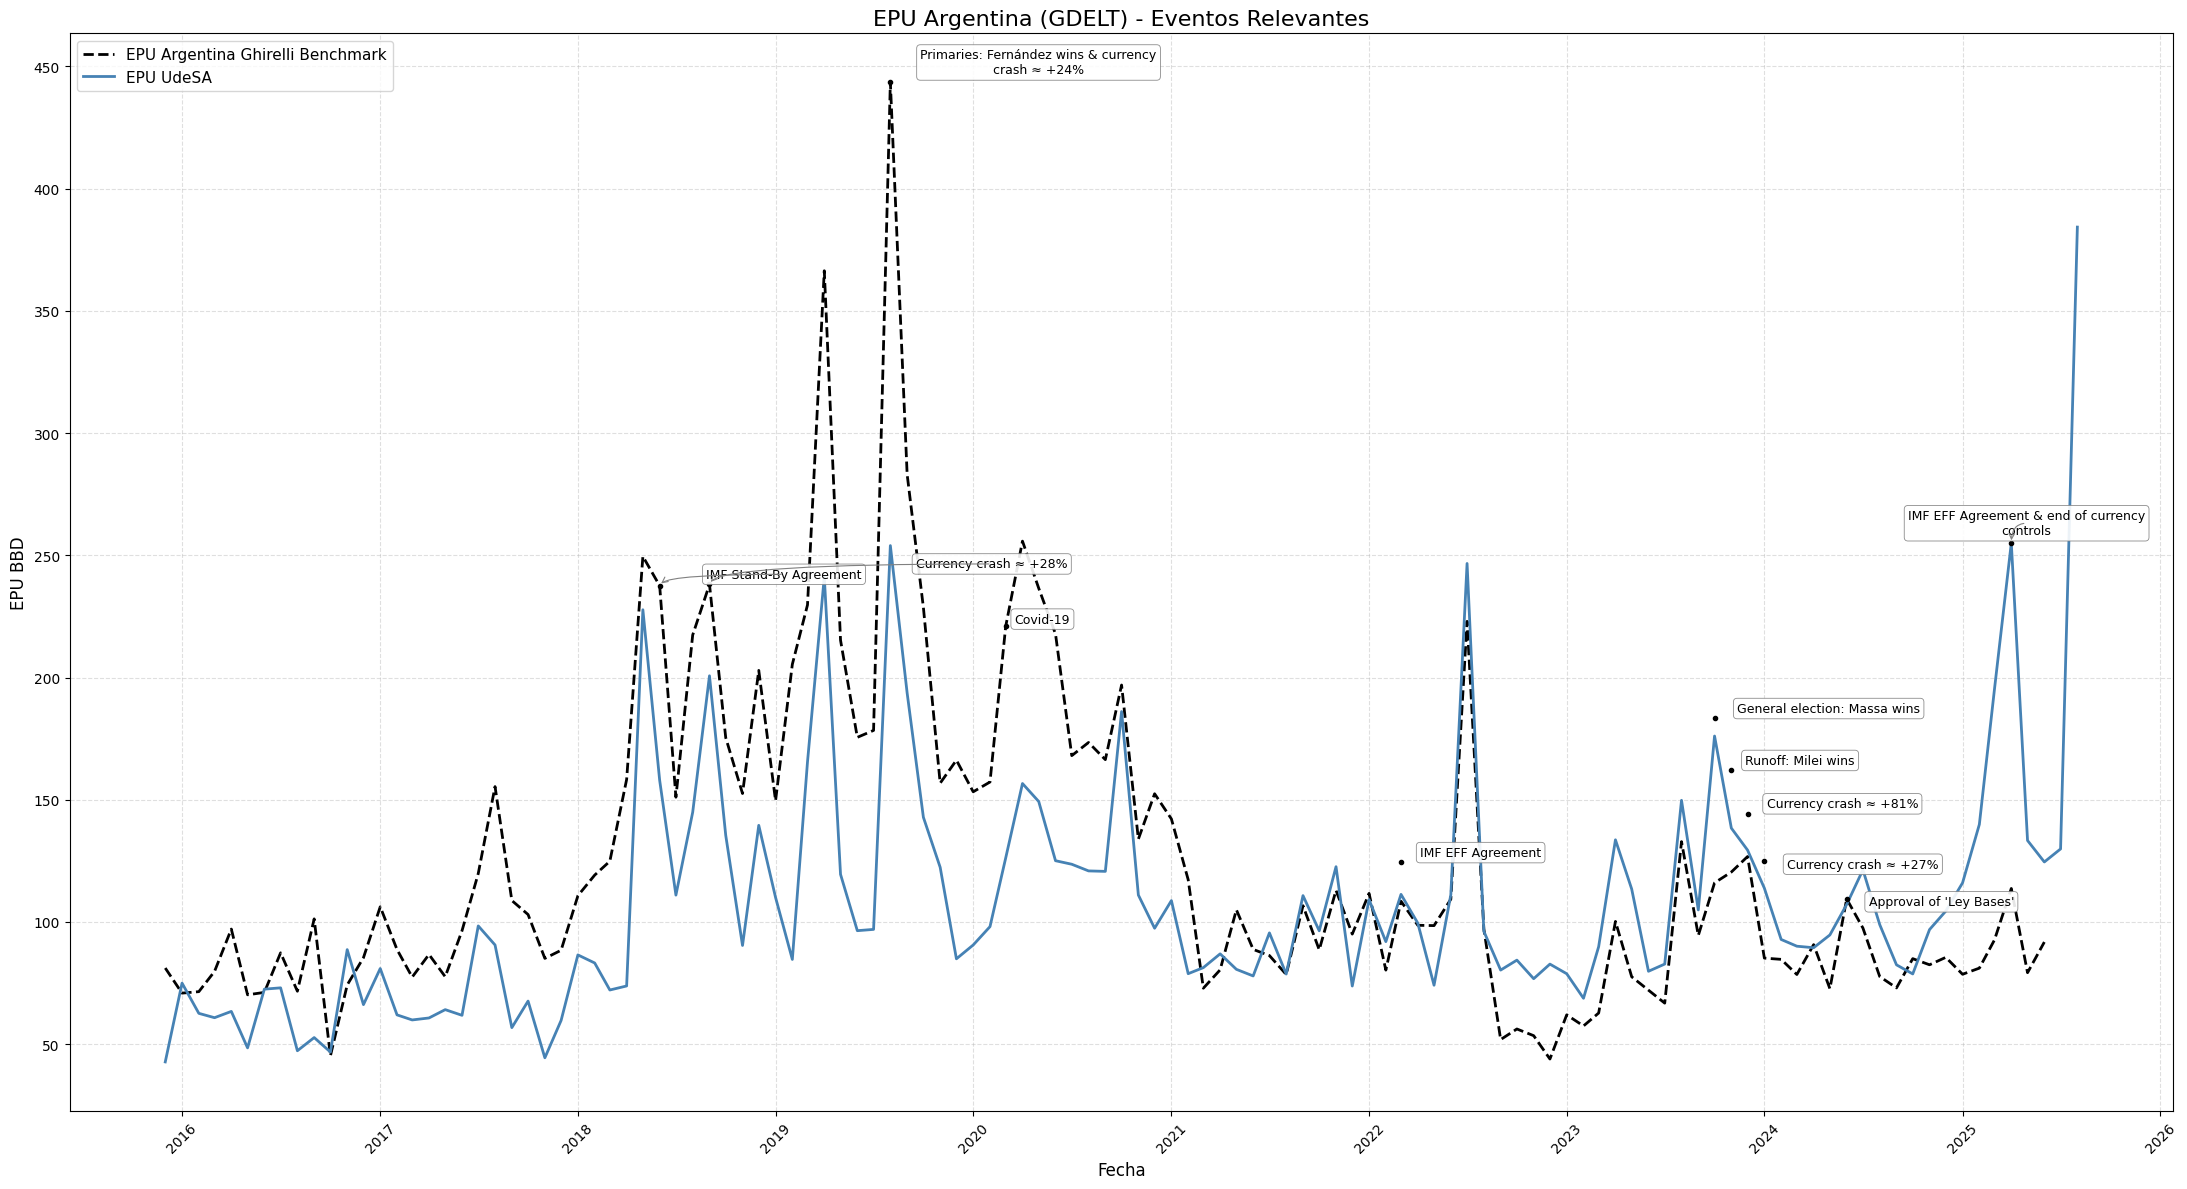

In [47]:
#Eventos
fig, (ax1) = plt.subplots(1, 1, figsize=(22, 12), sharex=True)

ax1.plot(df.loc[:, 'Benchmark Gdelt'], label='EPU Argentina Ghirelli Benchmark', color='black', linewidth=2, linestyle='--') #plot del benchmark
ax1.plot(df.loc[:, 'gdelt_maped_jp_all_media_with_sentiment'], label=f'EPU UdeSA', linewidth=2, linestyle='-', color='steelblue') #EPU

texts = []
for fecha_str, datos in events.items():
    fecha = pd.to_datetime(fecha_str + "-01")
    if fecha in df.index:
        valor = df.loc[fecha].max()
        evento_wrap = "\n".join(textwrap.wrap(datos["event"], width=40))  # multilínea
        texts.append(
            ax1.text(
                fecha, valor, evento_wrap,
                fontsize=9,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=0.6, alpha=0.9)
            )
        )
        ax1.plot(fecha, valor, 'ko', markersize=3)

adjust_text(
    texts,
    ax=ax1,
    expand_points=(1.1, 1.5),
    expand_text=(1.5, 2),
    arrowprops=dict(
        arrowstyle="->",
        color="gray",
        lw=0.8,
        connectionstyle="angle3,angleA=0,angleB=90"
    ),
    only_move={'points': 'y', 'text': 'xy'}
)

ax1.set_title("EPU Argentina (GDELT) - Eventos Relevantes", fontsize=16)
ax1.set_ylabel("EPU BBD", fontsize=12)
ax1.set_xlabel("Fecha", fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.4)
ax1.legend(loc='upper left', fontsize=11)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

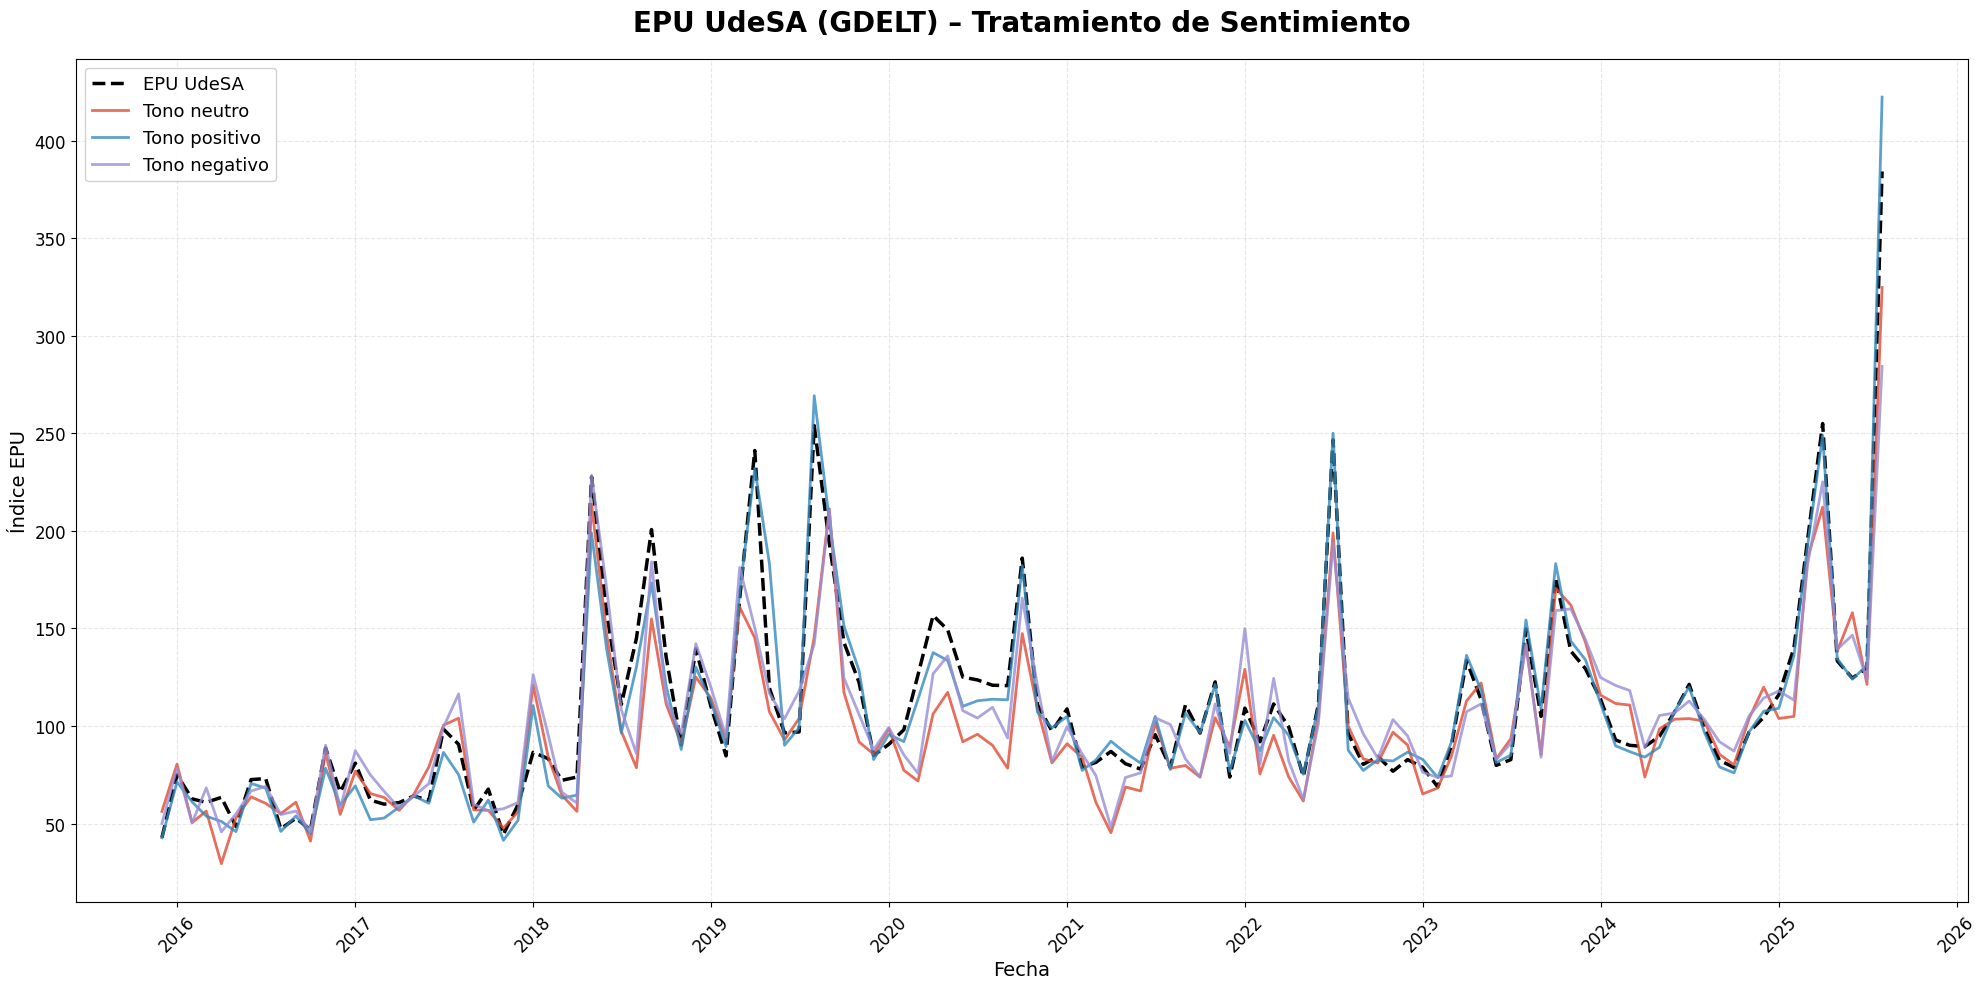

In [48]:
#sentimiento
fig, ax = plt.subplots(figsize=(20, 10))

colors = {
    "epu": "black",
    "neutral": "#E24A33",    # rojo anaranjado más elegante
    "positive": "#348ABD",   # azul intermedio
    "negative": "#988ED5"    # violeta
}

ax.plot(df['gdelt_maped_jp_all_media_with_sentiment'], label="EPU UdeSA", linewidth=2.5, linestyle="--", color=colors["epu"])
ax.plot(df['Exclude none adj by tone abs'], label="Tono neutro", linewidth=2, linestyle="-", color=colors["neutral"], alpha=0.8)
ax.plot(df['Exclude none adj by tone positive'], label="Tono positivo", linewidth=2, linestyle="-", color=colors["positive"], alpha=0.8)
ax.plot(df['Exclude none adj by tone negative'], label="Tono negativo", linewidth=2, linestyle="-", color=colors["negative"], alpha=0.8)

ax.set_title("EPU UdeSA (GDELT) – Tratamiento de Sentimiento", fontsize=20, fontweight="bold", pad=20)
ax.set_ylabel("Índice EPU", fontsize=14)
ax.set_xlabel("Fecha", fontsize=14)

ax.grid(True, linestyle="--", alpha=0.3)

ax.legend(loc="upper left", fontsize=13, frameon=True, framealpha=0.9)

ax.tick_params(axis="x", labelrotation=45, labelsize=12)
ax.tick_params(axis="y", labelsize=12)

plt.tight_layout()
plt.show()

In [61]:
epu_udesa = df['gdelt_maped_jp_all_media_with_sentiment'].copy()

print(monthly_percentages.index)
epu_udesa.index = pd.to_datetime(epu_udesa.index).to_period('M')
print(epu_udesa.index)

sentiment_data = pd.concat([epu_udesa, monthly_percentages], axis=1)


PeriodIndex(['2015-02', '2015-03', '2015-04', '2015-05', '2015-06', '2015-07',
             '2015-08', '2015-09', '2015-10', '2015-11',
             ...
             '2024-11', '2024-12', '2025-01', '2025-02', '2025-03', '2025-04',
             '2025-05', '2025-06', '2025-07', '2025-08'],
            dtype='period[M]', name='fecha', length=127)
PeriodIndex(['2015-12', '2016-01', '2016-02', '2016-03', '2016-04', '2016-05',
             '2016-06', '2016-07', '2016-08', '2016-09',
             ...
             '2024-11', '2024-12', '2025-01', '2025-02', '2025-03', '2025-04',
             '2025-05', '2025-06', '2025-07', '2025-08'],
            dtype='period[M]', name='fecha', length=117)


In [62]:
sentiment_data.dropna(inplace=True)
sentiment_data.rename(columns={
    'gdelt_maped_jp_all_media_with_sentiment': 'EPU UdeSA',
    'lt_-1': 'Negative Sentiment',
    'between': 'Neutral Sentiment',
    'gt_1': 'Positive Sentiment'
}, inplace=True)
cols_to_multiply = ['Neutral Sentiment', 'Positive Sentiment', 'Negative Sentiment']

sentiment_data[cols_to_multiply] = sentiment_data[cols_to_multiply].multiply(epu_udesa, axis=0)
sentiment_data.head()

,EPU UdeSA,Neutral Sentiment,Positive Sentiment,Negative Sentiment
fecha,,,,
2015-12,42.754031,11.922101,10.073784,20.758146
2016-01,74.993916,19.954492,16.094256,38.945168
2016-02,62.621963,17.603796,13.467445,31.550722
2016-03,60.841303,16.572511,13.192639,31.076153
2016-04,63.418571,16.935501,12.949120,33.533950


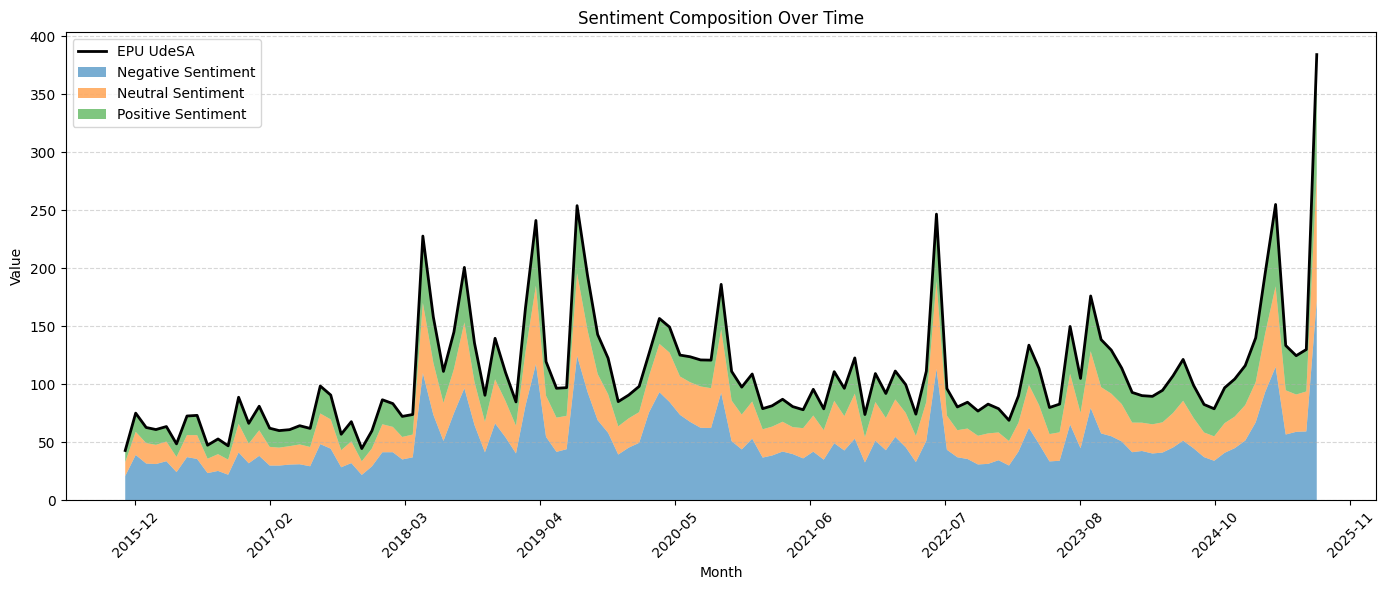

In [64]:
df_plot = sentiment_data.copy()
df_plot.index = df_plot.index.to_timestamp()
components = ['Negative Sentiment', 'Neutral Sentiment', 'Positive Sentiment']

plt.figure(figsize=(14, 6))
plt.plot(df_plot.index, df_plot['EPU UdeSA'], color='black', label='EPU UdeSA', linewidth=2)
plt.stackplot(df_plot.index,
              df_plot[components].T,
              labels=components,
              alpha=0.6)

plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(nbins=12))  # max 12 ticks
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))

plt.title("Sentiment Composition Over Time")
plt.ylabel("Value")
plt.xlabel("Month")
plt.legend(loc='upper left')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()